In [2]:
import pandas as pd

In [3]:
import matplotlib as plt

In [4]:
import seaborn as sns

In [5]:
print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

caminho = '/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/dados/archive/'

orders = pd.read_csv(caminho + 'olist_orders_dataset.csv')
items = pd.read_csv(caminho + 'olist_order_items_dataset.csv')
products = pd.read_csv(caminho + 'olist_products_dataset.csv')

print("Dados carregados! ✅")
print(f"Orders: {orders.shape}")
print(f"Items: {items.shape}")
print(f"Products: {products.shape}")

Dados carregados! ✅
Orders: (99441, 8)
Items: (112650, 7)
Products: (32951, 9)


In [11]:
# Visualizar as primeiras linhas de cada tabela
print("=== ORDERS ===")
print(orders.head())

print("\n=== ITEMS ===")
print(items.head())

print("\n=== PRODUCTS ===")
print(products.head())

=== ORDERS ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00   

In [12]:
# Verificar tipos de dados e valores nulos
print("=== ORDERS ===")
print(orders.info())

print("\n=== ITEMS ===")
print(items.info())

print("\n=== PRODUCTS ===")
print(products.info())

=== ORDERS ===
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None

=== ITEMS ===
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    


In [13]:
## Verificando os valores nulos

print("=== VALORES NULOS ===")
print("\nOrders:")
print(orders.isnull().sum())

print("\nItems:")
print(items.isnull().sum())

print("\nProducts:")
print(products.isnull().sum())

=== VALORES NULOS ===

Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [14]:
# Convertendo datas
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Filtrando apenas pedidos entregues
orders_delivered = orders[orders['order_status'] == 'delivered']

print(f"Total de pedidos: {len(orders)}")
print(f"Pedidos entregues: {len(orders_delivered)}")
print(f"Outros status: {len(orders) - len(orders_delivered)}")

Total de pedidos: 99441
Pedidos entregues: 96478
Outros status: 2963


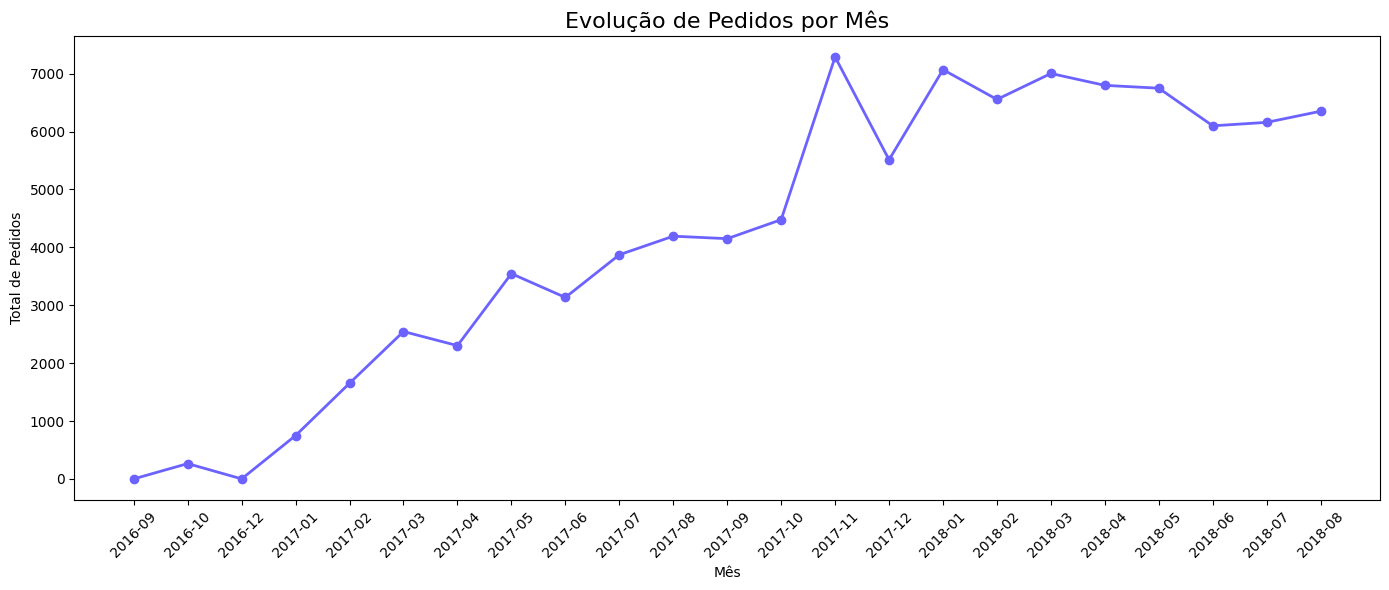

    mes_ano  total_pedidos
0   2016-09              1
1   2016-10            265
2   2016-12              1
3   2017-01            750
4   2017-02           1653
5   2017-03           2546
6   2017-04           2303
7   2017-05           3546
8   2017-06           3135
9   2017-07           3872
10  2017-08           4193
11  2017-09           4150
12  2017-10           4478
13  2017-11           7289
14  2017-12           5513
15  2018-01           7069
16  2018-02           6555
17  2018-03           7003
18  2018-04           6798
19  2018-05           6749
20  2018-06           6099
21  2018-07           6159
22  2018-08           6351


In [17]:
# Extraindo ano e mês
orders_delivered['mes_ano'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

# Contando pedidos por mês
pedidos_por_mes = orders_delivered.groupby('mes_ano').size().reset_index(name='total_pedidos')

# Plotando o gráfico
plt.figure(figsize=(14, 6))
plt.plot(pedidos_por_mes['mes_ano'].astype(str), pedidos_por_mes['total_pedidos'], marker='o', color='#6C63FF', linewidth=2)
plt.xticks(rotation=45)
plt.title('Evolução de Pedidos por Mês', fontsize=16)
plt.xlabel('Mês')
plt.ylabel('Total de Pedidos')
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/pedidos_por_mes.png')
plt.show()

print(pedidos_por_mes)

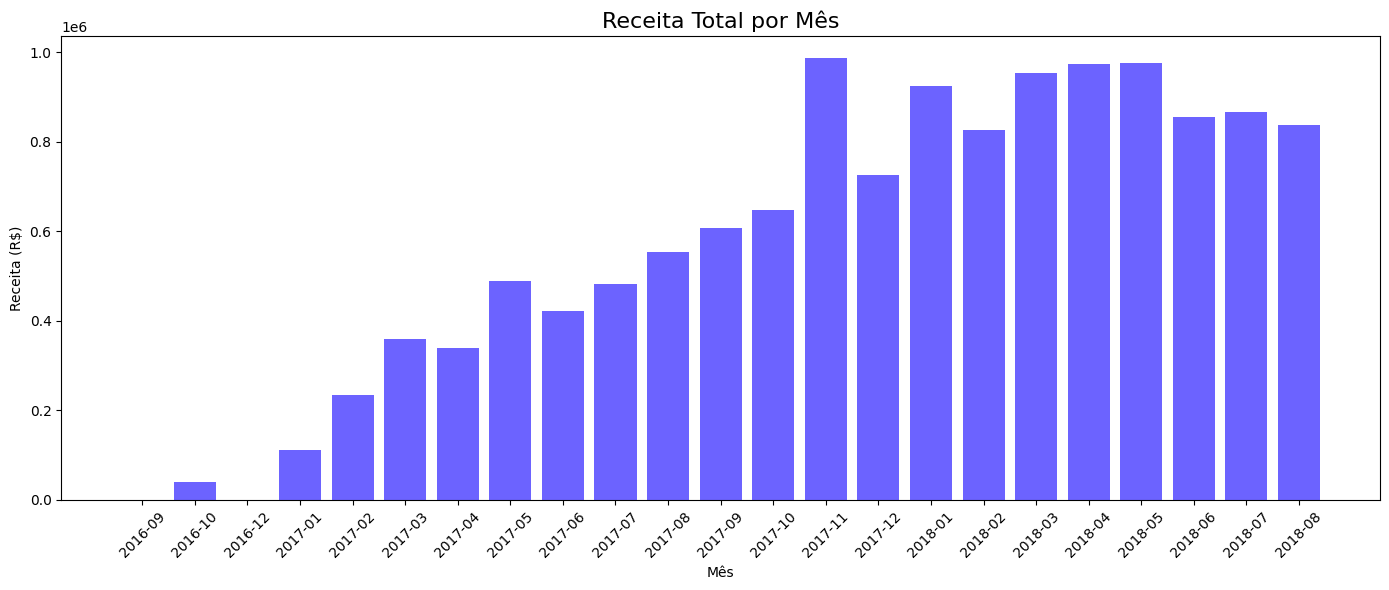

    mes_ano  receita_total
0   2016-09         134.97
1   2016-10       40325.11
2   2016-12          10.90
3   2017-01      111798.36
4   2017-02      234223.40
5   2017-03      359198.85
6   2017-04      340669.68
7   2017-05      489338.25
8   2017-06      421923.37
9   2017-07      481604.52
10  2017-08      554699.70
11  2017-09      607399.67
12  2017-10      648247.65
13  2017-11      987765.37
14  2017-12      726033.19
15  2018-01      924645.00
16  2018-02      826437.13
17  2018-03      953356.25
18  2018-04      973534.09
19  2018-05      977544.69
20  2018-06      856077.86
21  2018-07      867953.46
22  2018-08      838576.64


In [ ]:
## Cruzar os dados de orders com items para ver o faturamento:

# Unindo orders com items
df = orders_delivered.merge(items, on='order_id', how='inner')

# Receita por mês
receita_por_mes = df.groupby('mes_ano')['price'].sum().reset_index(name='receita_total')

# Plotando
plt.figure(figsize=(14, 6))
plt.bar(receita_por_mes['mes_ano'].astype(str), receita_por_mes['receita_total'], color='#6C63FF')
plt.xticks(rotation=45)
plt.title('Receita Total por Mês', fontsize=16)
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/receita_por_mes.png')
plt.show()

print(receita_por_mes)

/var/folders/zv/k4q2wbrd6m78wn25d0cz1rpw0000gp/T/ipykernel_56712/1289386129.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categorias, x='price', y='product_category_name', palette='viridis')


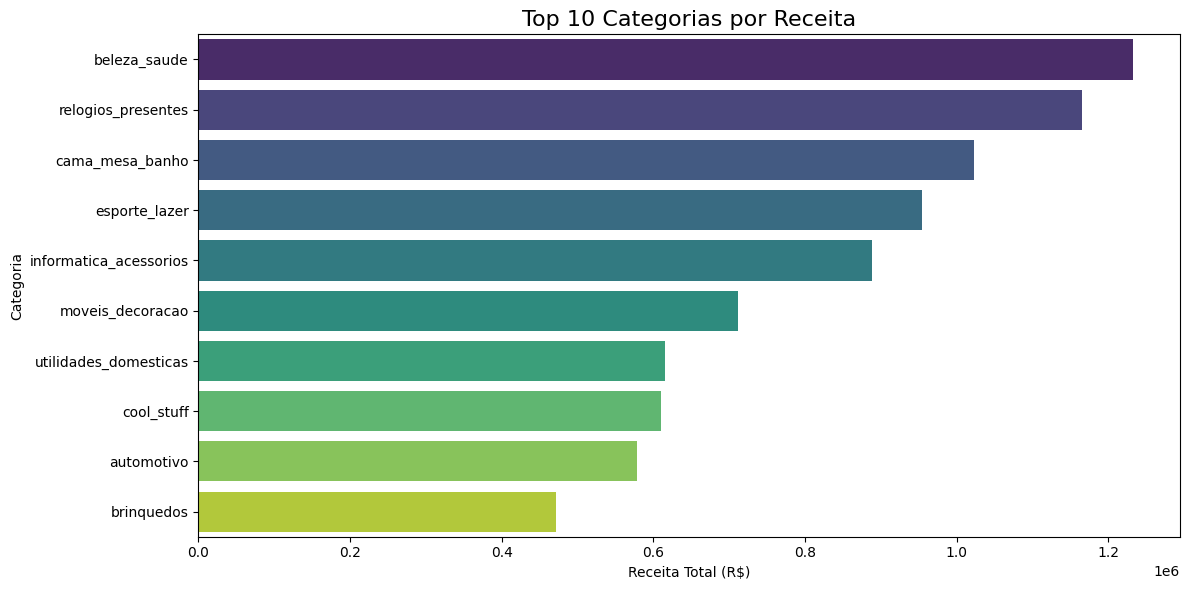

    product_category_name       price
0            beleza_saude  1233131.72
1      relogios_presentes  1166176.98
2         cama_mesa_banho  1023434.76
3           esporte_lazer   954852.55
4  informatica_acessorios   888724.61
5        moveis_decoracao   711927.69
6   utilidades_domesticas   615628.69
7              cool_stuff   610204.10
8              automotivo   578966.65
9              brinquedos   471286.48


In [19]:
## Top 10 categorias mais vendidas

# Unindo products para pegar as categorias
df_completo = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

# Top 10 categorias
top_categorias = df_completo.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()

# Plotando
plt.figure(figsize=(12, 6))
sns.barplot(data=top_categorias, x='price', y='product_category_name', palette='viridis')
plt.title('Top 10 Categorias por Receita', fontsize=16)
plt.xlabel('Receita Total (R$)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/top_categorias.png')
plt.show()

print(top_categorias)

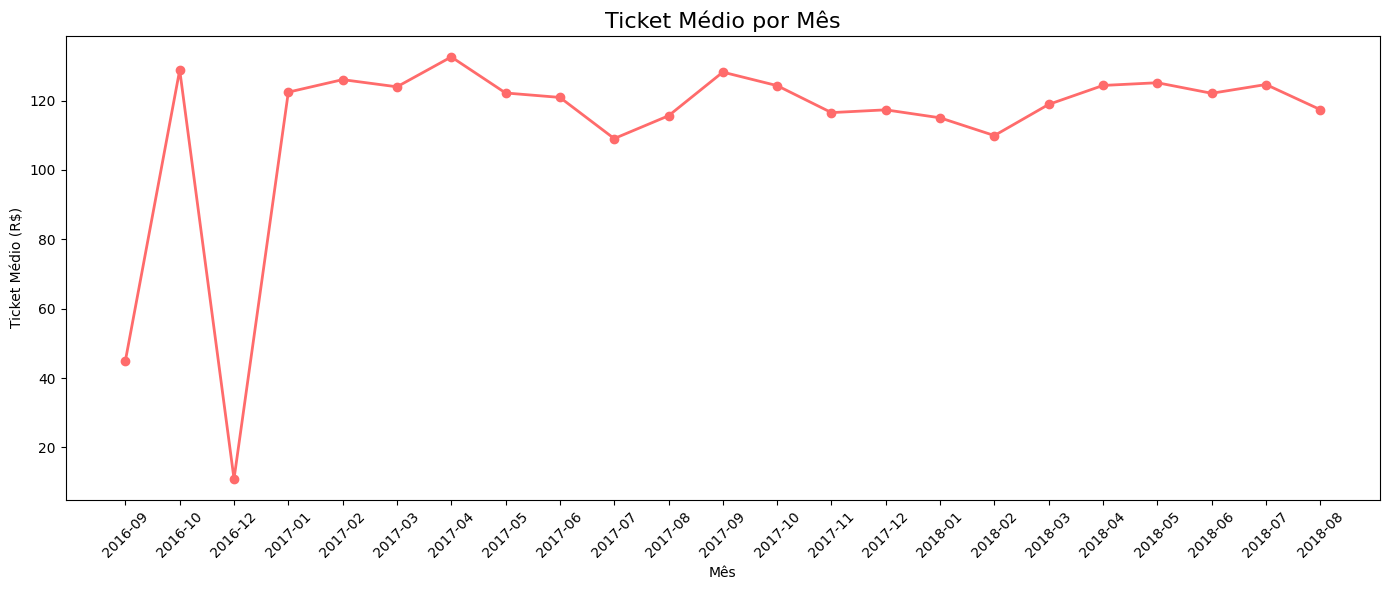

    mes_ano  ticket_medio
0   2016-09     44.990000
1   2016-10    128.834217
2   2016-12     10.900000
3   2017-01    122.451654
4   2017-02    126.062110
5   2017-03    123.989938
6   2017-04    132.607894
7   2017-05    122.212350
8   2017-06    120.929599
9   2017-07    109.058995
10  2017-08    115.634709
11  2017-09    128.224545
12  2017-10    124.328280
13  2017-11    116.550486
14  2017-12    117.348180
15  2018-01    115.048526
16  2018-02    109.927791
17  2018-03    118.916833
18  2018-04    124.381511
19  2018-05    125.165773
20  2018-06    122.122377
21  2018-07    124.652227
22  2018-08    117.414819


In [20]:
# Ticket médio por mês
ticket_medio = df.groupby('mes_ano')['price'].mean().reset_index(name='ticket_medio')

# Plotando
plt.figure(figsize=(14, 6))
plt.plot(ticket_medio['mes_ano'].astype(str), ticket_medio['ticket_medio'], marker='o', color='#FF6B6B', linewidth=2)
plt.xticks(rotation=45)
plt.title('Ticket Médio por Mês', fontsize=16)
plt.xlabel('Mês')
plt.ylabel('Ticket Médio (R$)')
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/ticket_medio.png')
plt.show()

print(ticket_medio)

In [25]:
## Calculando o tempo de entrega real e estimado

# Calculando tempo de entrega real e estimado
df_entrega = orders_delivered.copy()

df_entrega['tempo_real'] = (df_entrega['order_delivered_customer_date'] - 
                            df_entrega['order_purchase_timestamp']).dt.days

df_entrega['tempo_estimado'] = (df_entrega['order_estimated_delivery_date'] - 
                                df_entrega['order_purchase_timestamp']).dt.days

df_entrega['atraso'] = df_entrega['tempo_real'] - df_entrega['tempo_estimado']

print(f"Tempo médio de entrega real: {df_entrega['tempo_real'].mean():.1f} dias")
print(f"Tempo médio estimado: {df_entrega['tempo_estimado'].mean():.1f} dias")
print(f"Pedidos entregues antes do prazo: {(df_entrega['atraso'] < 0).sum()}")
print(f"Pedidos entregues com atraso: {(df_entrega['atraso'] > 0).sum()}")

Tempo médio de entrega real: 12.1 dias
Tempo médio estimado: 23.4 dias
Pedidos entregues antes do prazo: 87783
Pedidos entregues com atraso: 7307


In [ ]:
### 📋 O que os dados revelam:

## A Olist entrega em média 12 dias , bem abaixo dos 23 estimados
## 91% dos pedidos chegam antes do prazo
## Apenas 7,5% têm atraso

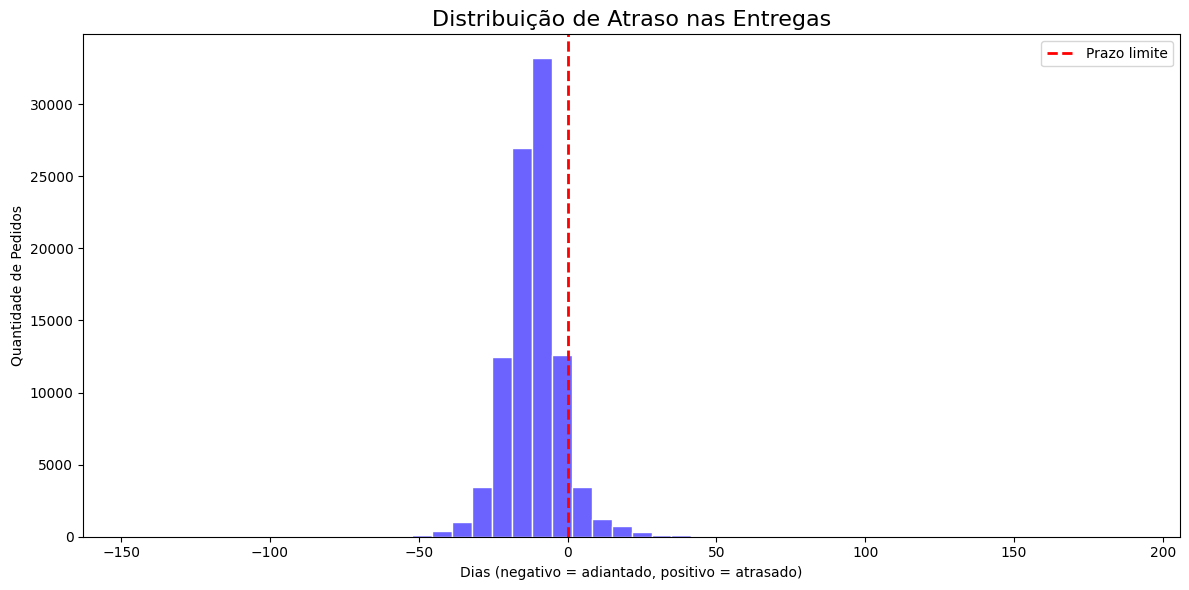

In [26]:
# Distribuição do atraso
plt.figure(figsize=(12, 6))
plt.hist(df_entrega['atraso'].dropna(), bins=50, color='#6C63FF', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Prazo limite')
plt.title('Distribuição de Atraso nas Entregas', fontsize=16)
plt.xlabel('Dias (negativo = adiantado, positivo = atrasado)')
plt.ylabel('Quantidade de Pedidos')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/atraso_entregas.png')
plt.show()

/var/folders/zv/k4q2wbrd6m78wn25d0cz1rpw0000gp/T/ipykernel_56712/2919094133.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pedidos_estado, x='customer_state', y='total_pedidos', palette='viridis')


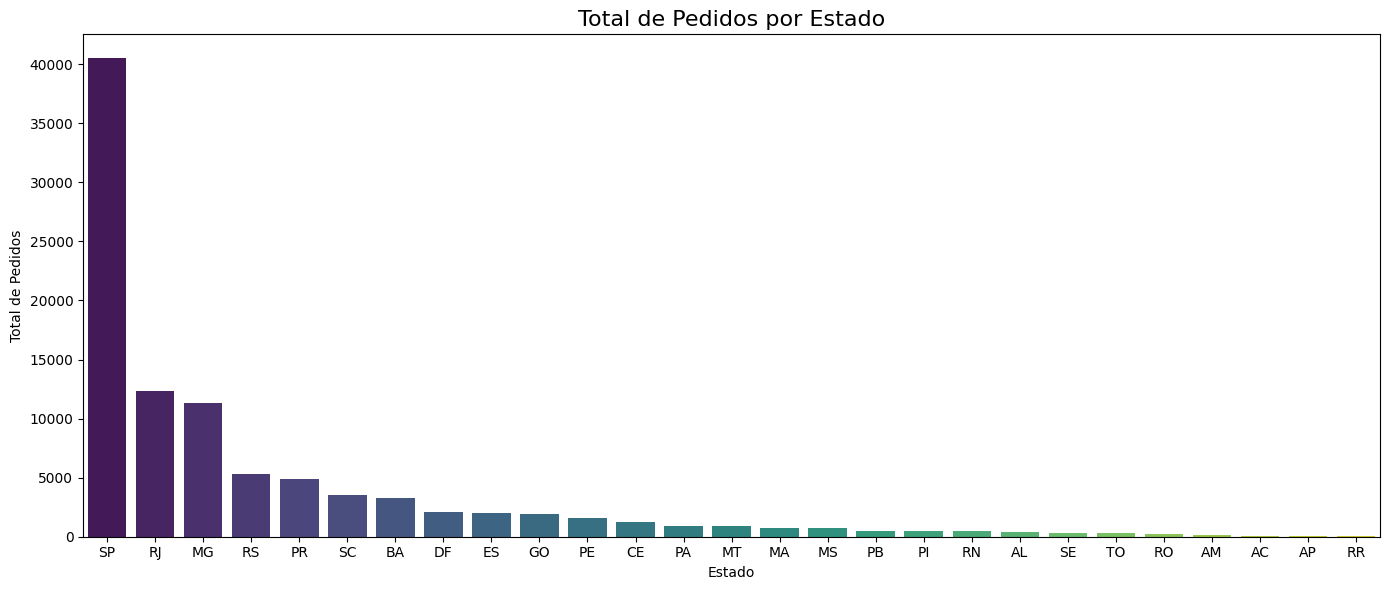

  customer_state  total_pedidos
0             SP          40501
1             RJ          12350
2             MG          11354
3             RS           5345
4             PR           4923
5             SC           3546
6             BA           3256
7             DF           2080
8             ES           1995
9             GO           1957


In [27]:
# Carregar dataset de clientes
customers = pd.read_csv('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/dados/archive/olist_customers_dataset.csv')

# Unindo com orders
df_estados = orders_delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Contando pedidos por estado
pedidos_estado = df_estados.groupby('customer_state').size().sort_values(ascending=False).reset_index(name='total_pedidos')

# Plotando
plt.figure(figsize=(14, 6))
sns.barplot(data=pedidos_estado, x='customer_state', y='total_pedidos', palette='viridis')
plt.title('Total de Pedidos por Estado', fontsize=16)
plt.xlabel('Estado')
plt.ylabel('Total de Pedidos')
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/pedidos_por_estado.png')
plt.show()

print(pedidos_estado.head(10))

/var/folders/zv/k4q2wbrd6m78wn25d0cz1rpw0000gp/T/ipykernel_56712/1901001971.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receita_estado, x='customer_state', y='receita_total', palette='magma')


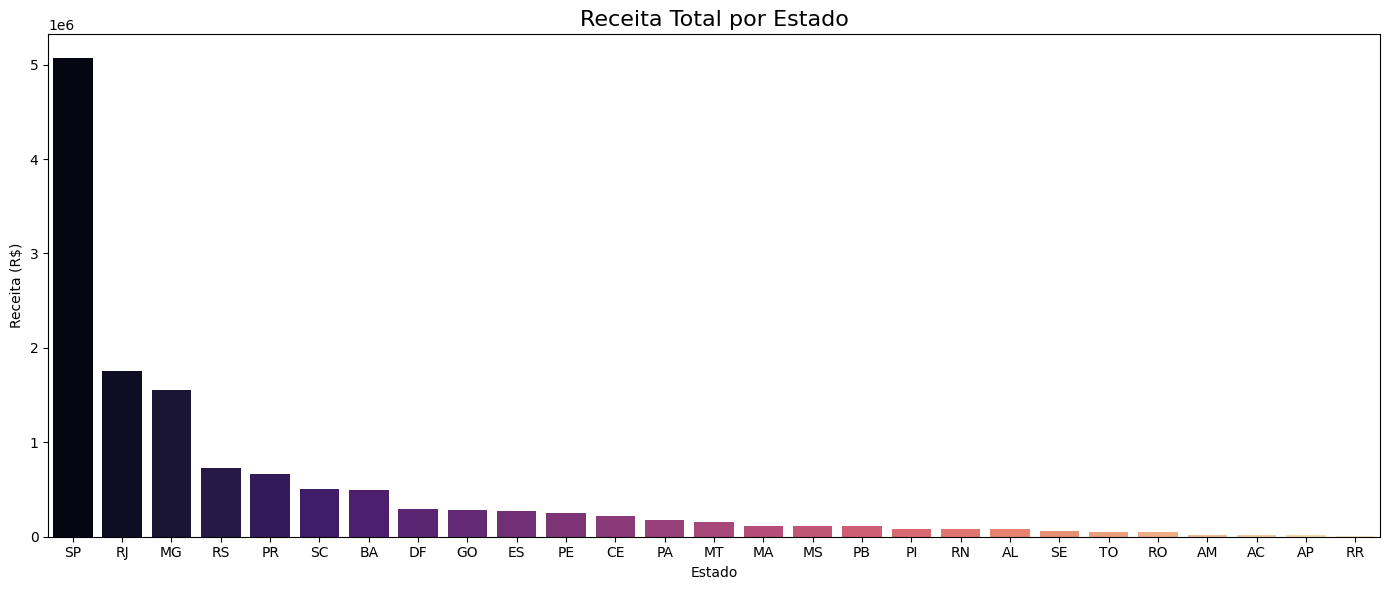

  customer_state  receita_total
0             SP     5067633.16
1             RJ     1759651.13
2             MG     1552481.83
3             RS      728897.47
4             PR      666063.51
5             SC      507012.13
6             BA      493584.14
7             DF      296498.41
8             GO      282836.70
9             ES      268643.45


In [28]:
# Unindo tudo
df_receita_estado = df_estados.merge(items[['order_id', 'price']], on='order_id', how='left')

# Receita por estado
receita_estado = df_receita_estado.groupby('customer_state')['price'].sum().sort_values(ascending=False).reset_index(name='receita_total')

# Plotando
plt.figure(figsize=(14, 6))
sns.barplot(data=receita_estado, x='customer_state', y='receita_total', palette='magma')
plt.title('Receita Total por Estado', fontsize=16)
plt.xlabel('Estado')
plt.ylabel('Receita (R$)')
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/receita_por_estado.png')
plt.show()

print(receita_estado.head(10))

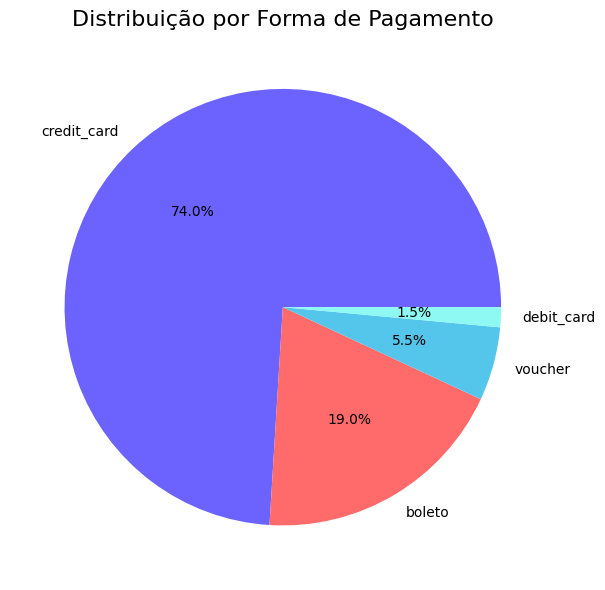

  payment_type  total
0  credit_card  74586
1       boleto  19191
2      voucher   5493
3   debit_card   1486


In [29]:
# Carregar dataset de pagamentos
pagamentos = pd.read_csv('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/dados/archive/olist_order_payments_dataset.csv')

# Unindo com orders entregues
df_pagamentos = orders_delivered.merge(pagamentos, on='order_id', how='left')

# Contando por tipo de pagamento
tipo_pagamento = df_pagamentos.groupby('payment_type').size().sort_values(ascending=False).reset_index(name='total')

# Plotando
plt.figure(figsize=(10, 6))
plt.pie(tipo_pagamento['total'], 
        labels=tipo_pagamento['payment_type'], 
        autopct='%1.1f%%',
        colors=['#6C63FF', '#FF6B6B', '#54C6EB', '#8EF9F3'])
plt.title('Distribuição por Forma de Pagamento', fontsize=16)
plt.tight_layout()
plt.savefig('/Users/anacarolina/Desktop/dados/projetos_pessoais/projeto_olist/imagens/formas_pagamento.png')
plt.show()

print(tipo_pagamento)